# **Forest Fires (Categorized Severity)**

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    f1_score,
    balanced_accuracy_score
    )
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import *
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
sns.set_style("whitegrid")

# Load Dataset

In [3]:
drive.mount('/content/drive')
path = "/content/drive/MyDrive/forestfires.csv"
df = pd.read_csv(path)
print("Dataset Shape:", df.shape)
print(df.head())

Mounted at /content/drive
Dataset Shape: (517, 13)
   X  Y month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain  area
0  7  5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0   0.0
1  7  4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0   0.0
2  7  4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0   0.0
3  8  6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2   0.0
4  8  6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0   0.0


## Basic Data Understanding

In [4]:
print("Dataset Shape:", df.shape)
print(df.info())
print(df.describe())

Dataset Shape: (517, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std 

# Data Cleaning

In [5]:
print("Missing Values:\n")
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Missing Values:

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64
Duplicates: 4


# Log Transformation
Reduce skewness of burned area


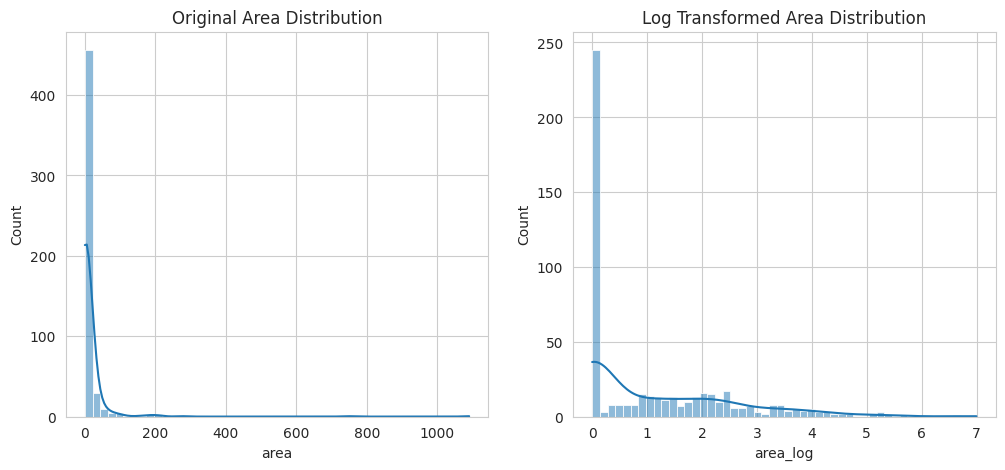

In [6]:
df['area_log'] = np.log1p(df['area'])
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['area'], bins=50, kde=True)
plt.title("Original Area Distribution")
plt.subplot(1,2,2)
sns.histplot(df['area_log'], bins=50, kde=True)
plt.title("Log Transformed Area Distribution")
plt.show()

# Create Target Variable (Severity)
Convert area into categories

severity
No Fire      244
Low Fire     136
High Fire    133
Name: count, dtype: int64


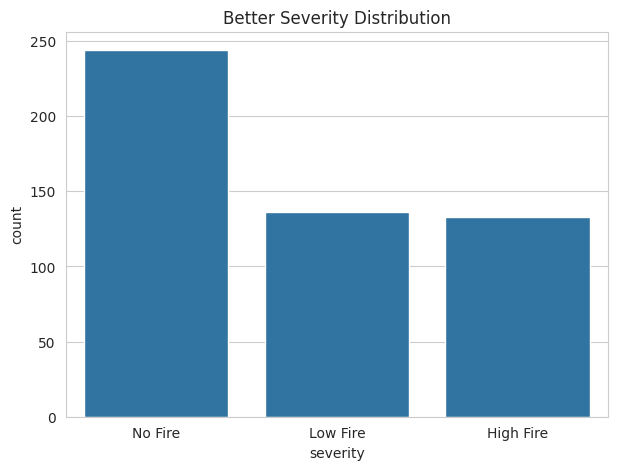

In [7]:
def categorize_area(area_log):
    if area_log == 0:
        return "No Fire"
    elif area_log <= 2:
        return "Low Fire"
    else:
        return "High Fire"
df['severity'] = df['area_log'].apply(categorize_area)
severity_map = {
    'No Fire': 0,
    'Low Fire': 1,
    'High Fire': 2
}
df['severity_encoded'] = df['severity'].map(severity_map)

print(df['severity'].value_counts())

plt.figure(figsize=(7,5))
sns.countplot(
    x='severity',
    data=df,
    order=['No Fire', 'Low Fire', 'High Fire']
)

plt.title("Better Severity Distribution")
plt.show()

# One-Hot Encoding

In [8]:
df = pd.get_dummies(
    df,
    columns=['month', 'day'],
    drop_first=True
)

# Correlation Heatmap

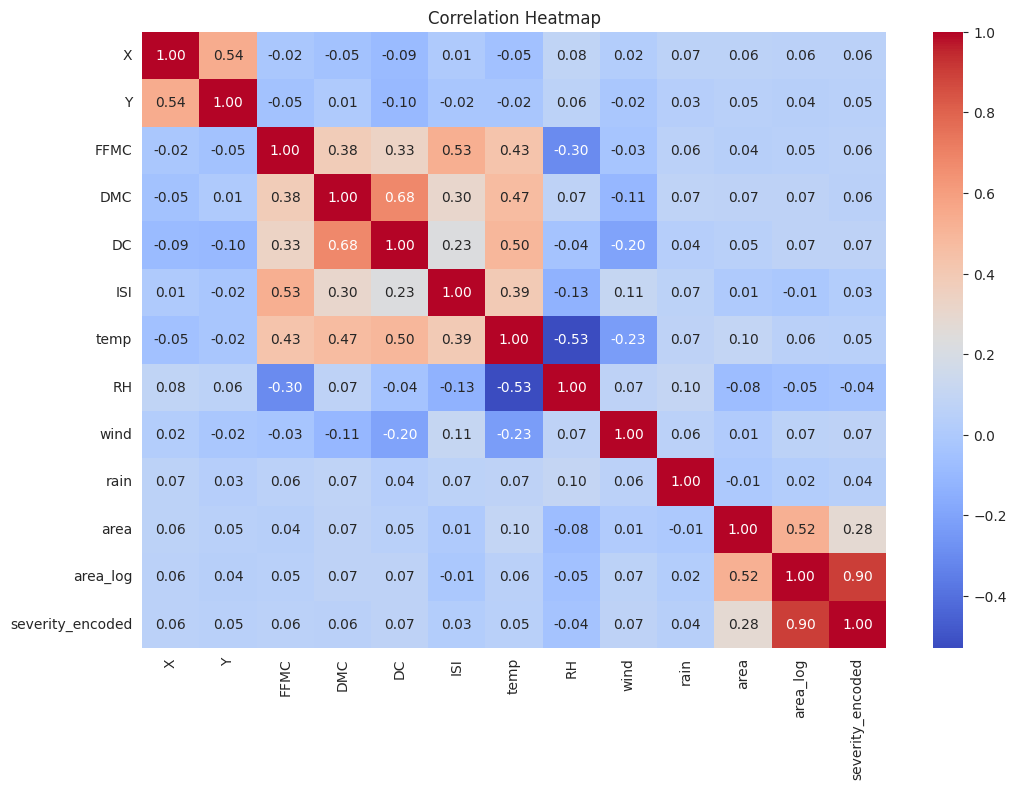

In [9]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# Feature & Target Selection
Separate input and output

In [10]:
drop_columns = [
    'severity','severity_encoded',
    'area','area_log']
X = df.drop(columns=drop_columns)
y = df['severity_encoded']
print("Selected features:")
print(X.columns)

Selected features:
Index(['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain',
       'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'day_mon', 'day_sat', 'day_sun', 'day_thu', 'day_tue',
       'day_wed'],
      dtype='object')


# TRAIN TEST SPLIT

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2, random_state=42, stratify=y)
print("\nClass distribution (train):")
print(y_train.value_counts())


Class distribution (train):
severity_encoded
0    195
1    109
2    106
Name: count, dtype: int64


# SMOTE (ONLY ON TRAIN DATA)


After SMOTE:
severity_encoded
0    195
2    195
1    195
Name: count, dtype: int64


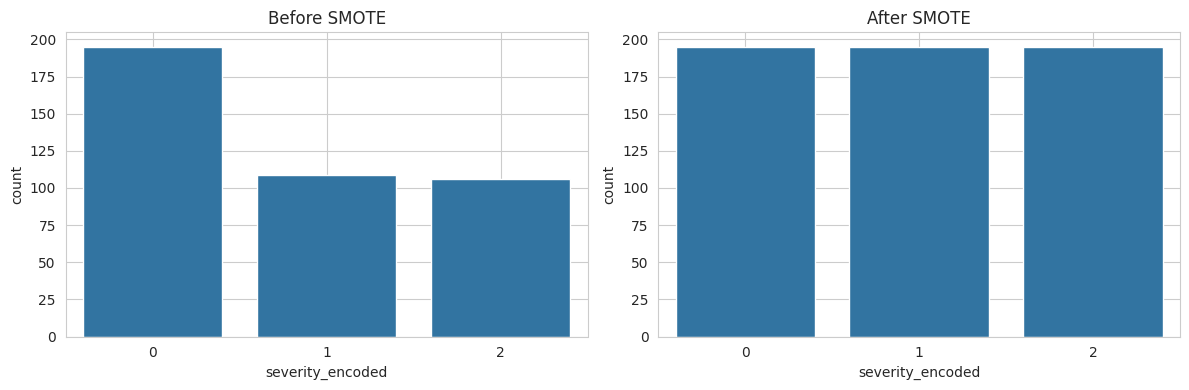

In [12]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Before SMOTE")
axes[0].grid(True)

sns.countplot(x=y_train_smote, ax=axes[1])
axes[1].set_title("After SMOTE")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# RANDOM FOREST
# Hyperparameter Tuning

In [34]:
estimators = [100, 300, 500, 700, 1000]
depths = [5,10,15,20,25,30,35,40,45,50]
splits = [2,5,10]
leaves = [1,2,4]
rf_results = []
for n in estimators:
    for d in depths:
        for s in splits:
            for l in leaves:
                model = RandomForestClassifier(
                    n_estimators=n, max_depth=d,
                    min_samples_split=s, min_samples_leaf=l,
                    class_weight='balanced', random_state=42
                )
                model.fit(X_train_smote, y_train_smote)
                y_pred = model.predict(X_test)
                acc = accuracy_score(y_test, y_pred)
                f1  = f1_score(y_test, y_pred, average='macro')
                rf_results.append((n, d, s, l, acc, f1))

                print(f"n={n}, depth={d}, split={s}, leaf={l} | Acc={acc:.4f} | F1={f1:.4f}")
                rf_df = pd.DataFrame(rf_results, columns=[
    'n_estimators', 'max_depth', 'min_split', 'min_leaf', 'Accuracy', 'F1'
])


n=100, depth=5, split=2, leaf=1 | Acc=0.4757 | F1=0.4386
n=100, depth=5, split=2, leaf=2 | Acc=0.4854 | F1=0.4504
n=100, depth=5, split=2, leaf=4 | Acc=0.4466 | F1=0.4011
n=100, depth=5, split=5, leaf=1 | Acc=0.4854 | F1=0.4336
n=100, depth=5, split=5, leaf=2 | Acc=0.4854 | F1=0.4402
n=100, depth=5, split=5, leaf=4 | Acc=0.4466 | F1=0.4011
n=100, depth=5, split=10, leaf=1 | Acc=0.4951 | F1=0.4586
n=100, depth=5, split=10, leaf=2 | Acc=0.4757 | F1=0.4308
n=100, depth=5, split=10, leaf=4 | Acc=0.4757 | F1=0.4395
n=100, depth=10, split=2, leaf=1 | Acc=0.4951 | F1=0.4527
n=100, depth=10, split=2, leaf=2 | Acc=0.5049 | F1=0.4656
n=100, depth=10, split=2, leaf=4 | Acc=0.4854 | F1=0.4457
n=100, depth=10, split=5, leaf=1 | Acc=0.5243 | F1=0.4801
n=100, depth=10, split=5, leaf=2 | Acc=0.4854 | F1=0.4404
n=100, depth=10, split=5, leaf=4 | Acc=0.4854 | F1=0.4457
n=100, depth=10, split=10, leaf=1 | Acc=0.5049 | F1=0.4755
n=100, depth=10, split=10, leaf=2 | Acc=0.5146 | F1=0.4724
n=100, depth=10, s

# Plot in Graph

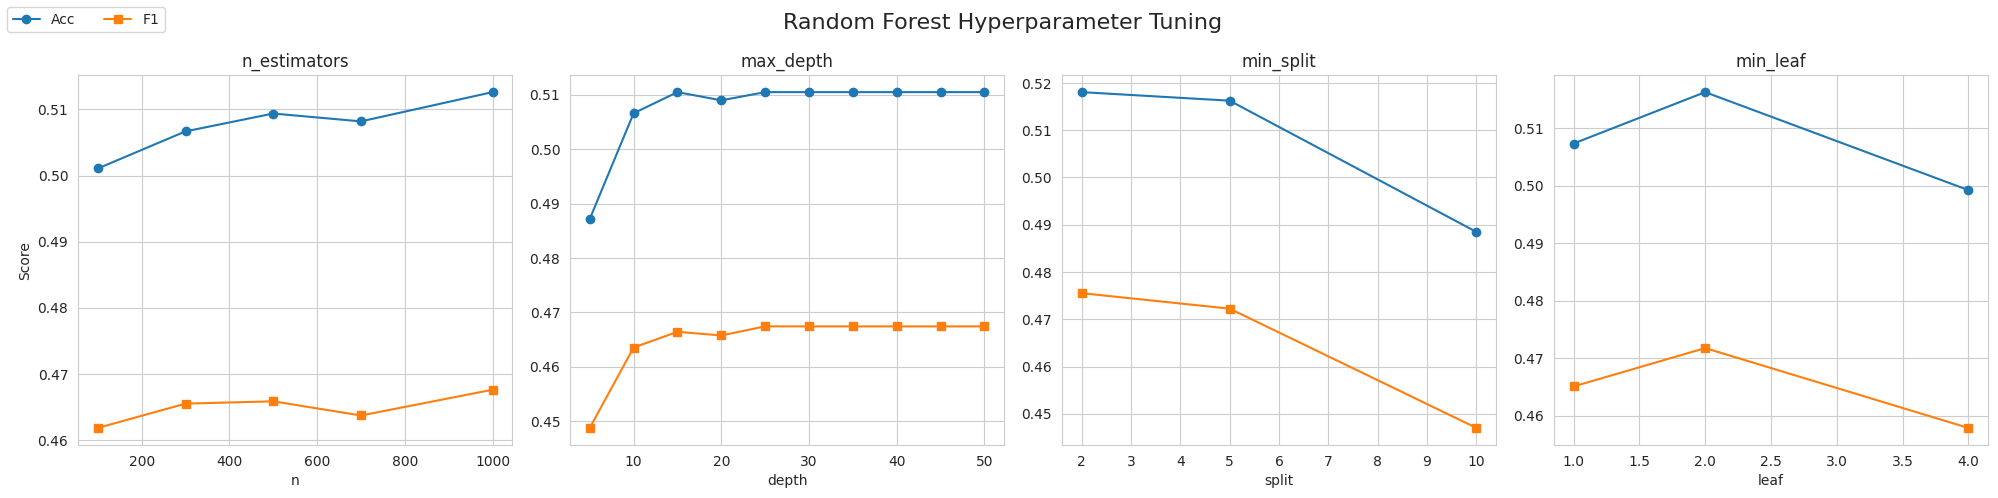

In [84]:
fig, axes = plt.subplots(1, 4, figsize=(20,5))

# n_estimators
grouped = rf_df.groupby('n_estimators').mean(numeric_only=True)
axes[0].plot(grouped.index, grouped['Accuracy'], marker='o', label='Acc')
axes[0].plot(grouped.index, grouped['F1'], marker='s', label='F1')
axes[0].set_title("n_estimators")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Score")
axes[0].grid(True)

# max_depth
grouped = rf_df.groupby('max_depth').mean(numeric_only=True)
axes[1].plot(grouped.index, grouped['Accuracy'], marker='o')
axes[1].plot(grouped.index, grouped['F1'], marker='s')
axes[1].set_title("max_depth")
axes[1].set_xlabel("depth")
axes[1].grid(True)

# min_samples_split
grouped = rf_df.groupby('min_split').mean(numeric_only=True)
axes[2].plot(grouped.index, grouped['Accuracy'], marker='o')
axes[2].plot(grouped.index, grouped['F1'], marker='s')
axes[2].set_title("min_split")
axes[2].set_xlabel("split")
axes[2].grid(True)

#min_samples_leaf
grouped = rf_df.groupby('min_leaf').mean(numeric_only=True)
axes[3].plot(grouped.index, grouped['Accuracy'], marker='o')
axes[3].plot(grouped.index, grouped['F1'], marker='s')
axes[3].set_title("min_leaf")
axes[3].set_xlabel("leaf")
axes[3].grid(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2)

plt.suptitle("Random Forest Hyperparameter Tuning", fontsize=16)
plt.tight_layout()
plt.show()

In [85]:
best_result = max(rf_results, key=lambda x: x[4])

best_rf_n = best_result[0]
best_rf_depth = best_result[1]
best_rf_split = best_result[2]
best_rf_leaf = best_result[3]
best_rf_acc = best_result[4]

print("\nBest Parameters:")
print("n_estimators:", best_rf_n)
print("max_depth:", best_rf_depth)
print("min_samples_split:", best_rf_split)
print("min_samples_leaf:", best_rf_leaf)
print("Best Accuracy:", best_rf_acc)


Best Parameters:
n_estimators: 300
max_depth: 10
min_samples_split: 5
min_samples_leaf: 1
Best Accuracy: 0.5436893203883495


Train with the Best Values

In [86]:
best_rf = RandomForestClassifier(
    n_estimators=best_rf_n,
    max_depth=best_rf_depth,
    min_samples_split=best_rf_split,
    min_samples_leaf=best_rf_leaf,
    class_weight='balanced',
    random_state=42
)
best_rf.fit(X_train_smote, y_train_smote)
y_pred_rf_final = best_rf.predict(X_test)
print("="*60)
print("FINAL RANDOM FOREST MODEL")
print("="*60)
print("\nAccuracy:", accuracy_score(y_test, y_pred_rf_final))
print("F1 Score (Macro):", f1_score(y_test, y_pred_rf_final, average='macro'))
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred_rf_final,
    target_names=['No Fire', 'Low Fire', 'High Fire']
))

FINAL RANDOM FOREST MODEL

Accuracy: 0.5436893203883495
F1 Score (Macro): 0.4993464052287582

Classification Report:

              precision    recall  f1-score   support

     No Fire       0.62      0.71      0.67        49
    Low Fire       0.46      0.41      0.43        27
   High Fire       0.43      0.37      0.40        27

    accuracy                           0.54       103
   macro avg       0.51      0.50      0.50       103
weighted avg       0.53      0.54      0.54       103



# FEATURE IMPORTANCE

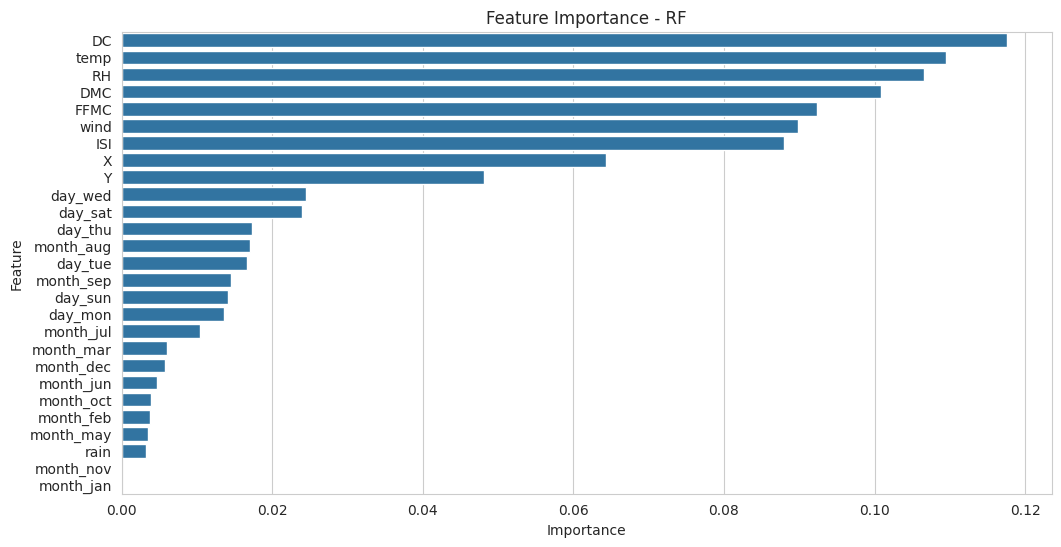


Top Features:
     Feature  Importance
4        DC    0.117640
6      temp    0.109507
7        RH    0.106564
3       DMC    0.100804
2      FFMC    0.092299
8      wind    0.089775
5       ISI    0.087936
0         X    0.064355
1         Y    0.048168
26  day_wed    0.024542


In [40]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Feature Importance - RF")
plt.show()

print("\nTop Features:\n", importance_df.head(10))

# Train the model with Selected Features

In [41]:
X_selected = X[['temp', 'DC', 'RH', 'DMC', 'ISI', 'FFMC', 'wind']]
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)
X_train_sel_smote, y_train_sel_smote = smote.fit_resample(
    X_train_sel, y_train_sel)
rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42)
rf_final.fit(X_train_sel_smote, y_train_sel_smote)
y_pred_final = rf_final.predict(X_test_sel)
from sklearn.metrics import classification_report, accuracy_score, f1_score

print("="*60)
print("FINAL RANDOM FOREST (FEATURE SELECTED MODEL)")
print("="*60)

print("\nAccuracy:", accuracy_score(y_test_sel, y_pred_final))

print("\nF1 Score (Macro):", f1_score(y_test_sel, y_pred_final, average='macro'))

print("\nClassification Report:\n")

print(classification_report(
    y_test_sel,
    y_pred_final,
    target_names=['No Fire', 'Low Fire', 'High Fire']
))

FINAL RANDOM FOREST (FEATURE SELECTED MODEL)

Accuracy: 0.5533980582524272

F1 Score (Macro): 0.5174503458341265

Classification Report:

              precision    recall  f1-score   support

     No Fire       0.63      0.69      0.66        49
    Low Fire       0.52      0.48      0.50        27
   High Fire       0.42      0.37      0.39        27

    accuracy                           0.55       103
   macro avg       0.52      0.52      0.52       103
weighted avg       0.55      0.55      0.55       103



# RF CONFUSION MATRIX

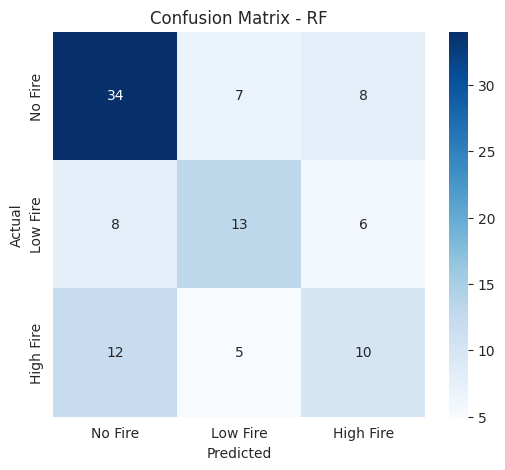

In [42]:
cm = confusion_matrix(y_test_sel, y_pred_final)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Fire','Low Fire','High Fire'],
    yticklabels=['No Fire','Low Fire','High Fire']
)

plt.title("Confusion Matrix - RF")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# RF ROC CURVE

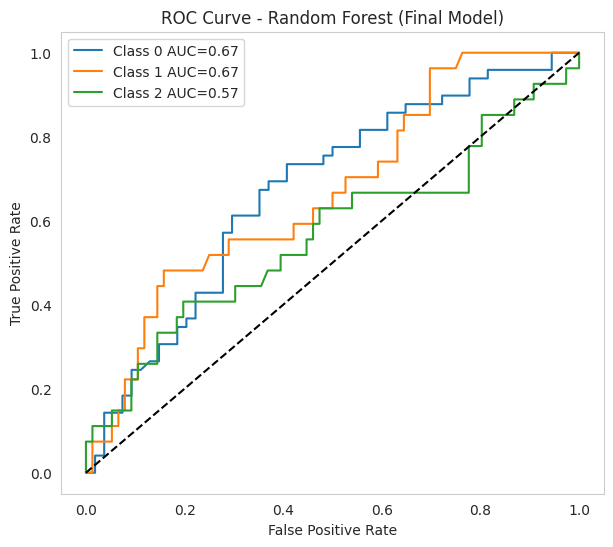

In [43]:
y_test_bin = label_binarize(y_test_sel, classes=[0,1,2])
y_prob = rf_final.predict_proba(X_test_sel)

plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} AUC={roc_auc:.2f}")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve - Random Forest (Final Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

# GRADIENT BOOSTING
# Hyperparameter Tuning

In [81]:
estimators = [100, 300, 500, 700, 1000]
learning_rates = [0.01, 0.03, 0.05, 0.1]
depths = [2, 3, 4, 5, 6]
subsamples = [0.6, 0.7, 0.8, 0.9, 1.0]


gb_results = []
for n in estimators:
    for lr in learning_rates:
        for d in depths:
            for s in subsamples:

                model = GradientBoostingClassifier(
                    n_estimators=n,
                    learning_rate=lr,
                    max_depth=d,
                    subsample=s,
                    random_state=42
                )

                model.fit(X_train_smote, y_train_smote)

                y_pred = model.predict(X_test)

                acc = accuracy_score(y_test, y_pred)
                f1  = f1_score(y_test, y_pred, average='macro')

                gb_results.append((n, lr, d, s, acc, f1))

                print(f"n={n}, lr={lr}, depth={d}, subsample={s} | Acc={acc:.4f} | F1={f1:.4f}")
                gb_df = pd.DataFrame(gb_results, columns=[
    'n_estimators', 'learning_rate', 'max_depth', 'subsample', 'Accuracy', 'F1'
])


n=100, lr=0.01, depth=2, subsample=0.6 | Acc=0.4466 | F1=0.3992
n=100, lr=0.01, depth=2, subsample=0.7 | Acc=0.4466 | F1=0.3973
n=100, lr=0.01, depth=2, subsample=0.8 | Acc=0.4369 | F1=0.3838
n=100, lr=0.01, depth=2, subsample=0.9 | Acc=0.4466 | F1=0.3845
n=100, lr=0.01, depth=2, subsample=1.0 | Acc=0.4563 | F1=0.3919
n=100, lr=0.01, depth=3, subsample=0.6 | Acc=0.4563 | F1=0.4202
n=100, lr=0.01, depth=3, subsample=0.7 | Acc=0.4757 | F1=0.4236
n=100, lr=0.01, depth=3, subsample=0.8 | Acc=0.4660 | F1=0.4043
n=100, lr=0.01, depth=3, subsample=0.9 | Acc=0.4369 | F1=0.3701
n=100, lr=0.01, depth=3, subsample=1.0 | Acc=0.4175 | F1=0.3627
n=100, lr=0.01, depth=4, subsample=0.6 | Acc=0.5049 | F1=0.4672
n=100, lr=0.01, depth=4, subsample=0.7 | Acc=0.5049 | F1=0.4635
n=100, lr=0.01, depth=4, subsample=0.8 | Acc=0.5049 | F1=0.4608
n=100, lr=0.01, depth=4, subsample=0.9 | Acc=0.4951 | F1=0.4469
n=100, lr=0.01, depth=4, subsample=1.0 | Acc=0.4757 | F1=0.4120
n=100, lr=0.01, depth=5, subsample=0.6 |

# Plot in Graph

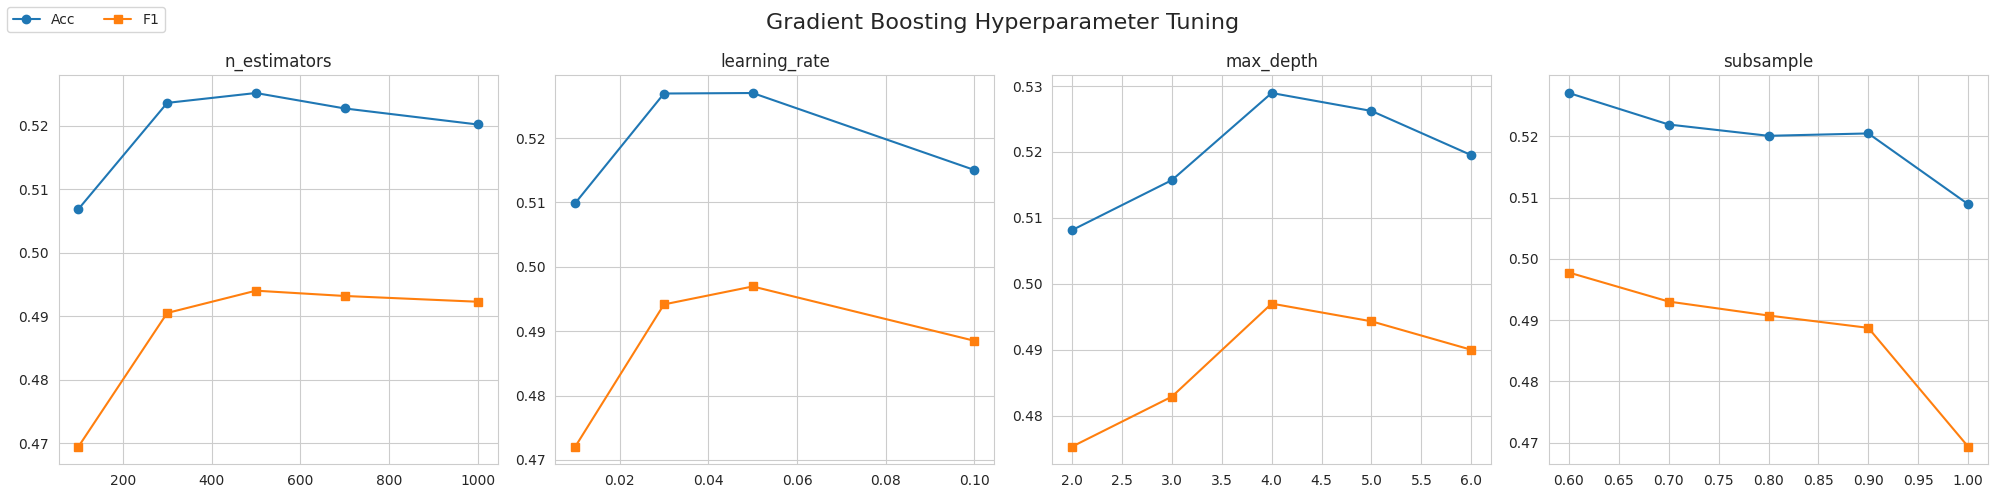

In [87]:
fig, axes = plt.subplots(1, 4, figsize=(20,5))
# n_estimators
grouped = gb_df.groupby('n_estimators').mean(numeric_only=True)
axes[0].plot(grouped.index, grouped['Accuracy'], marker='o', label='Acc')
axes[0].plot(grouped.index, grouped['F1'], marker='s', label='F1')
axes[0].set_title("n_estimators")
axes[0].grid(True)

# learning_rate
grouped = gb_df.groupby('learning_rate').mean(numeric_only=True)
axes[1].plot(grouped.index, grouped['Accuracy'], marker='o')
axes[1].plot(grouped.index, grouped['F1'], marker='s')
axes[1].set_title("learning_rate")
axes[1].grid(True)

# max_depth
grouped = gb_df.groupby('max_depth').mean(numeric_only=True)
axes[2].plot(grouped.index, grouped['Accuracy'], marker='o')
axes[2].plot(grouped.index, grouped['F1'], marker='s')
axes[2].set_title("max_depth")
axes[2].grid(True)

# subsample
grouped = gb_df.groupby('subsample').mean(numeric_only=True)
axes[3].plot(grouped.index, grouped['Accuracy'], marker='o')
axes[3].plot(grouped.index, grouped['F1'], marker='s')
axes[3].set_title("subsample")
axes[3].grid(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2)

plt.suptitle("Gradient Boosting Hyperparameter Tuning", fontsize=16)
plt.tight_layout()
plt.show()

# Select Best Parameters

In [46]:
best_result = max(gb_results, key=lambda x: x[4])
best_gb_n = best_result[0]
best_gb_lr = best_result[1]
best_gb_depth = best_result[2]
best_gb_subsample = best_result[3]
best_gb_acc = best_result[4]

print("\nBest Parameters:")
print("n_estimators:", best_gb_n)
print("learning_rate:", best_gb_lr)
print("max_depth:", best_gb_depth)
print("subsample:", best_gb_subsample)
print("Best Accuracy:", best_gb_acc)


Best Parameters:
n_estimators: 500
learning_rate: 0.05
max_depth: 2
subsample: 0.8
Best Accuracy: 0.5728155339805825


# Train the model with Best Parameters

In [47]:
# ==========================================
# FINAL SAFE DATA SPLIT
# ==========================================

X = df.drop(columns=['severity','severity_encoded','area','area_log'])
y = df['severity_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("CHECK y_train_smote TYPE:", type(y_train_smote))
print("Unique classes:", np.unique(y_train_smote))

CHECK y_train_smote TYPE: <class 'pandas.core.series.Series'>
Unique classes: [0 1 2]


In [55]:
gb_final = GradientBoostingClassifier(
    n_estimators=best_gb_n,
    learning_rate=best_gb_lr,
    max_depth=best_gb_depth,
    subsample=best_gb_subsample,
    random_state=42
)
gb_final.fit(X_train_smote, y_train_smote)
X_test_aligned = X_test.reindex(columns=X_train_smote.columns, fill_value=0)
y_pred_final = gb_final.predict(X_test_aligned)
y_prob_final = gb_final.predict_proba(X_test_aligned)
print("="*60)
print("FINAL GRADIENT BOOSTING MODEL")
print("="*60)
print("\nAccuracy:", accuracy_score(y_test, y_pred_final))
print("F1 Score (Macro):", f1_score(y_test, y_pred_final, average='macro'))
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=['No Fire', 'Low Fire', 'High Fire']
))

FINAL GRADIENT BOOSTING MODEL

Accuracy: 0.5728155339805825
F1 Score (Macro): 0.552089522677758

Classification Report:

              precision    recall  f1-score   support

     No Fire       0.64      0.65      0.65        49
    Low Fire       0.48      0.52      0.50        27
   High Fire       0.54      0.48      0.51        27

    accuracy                           0.57       103
   macro avg       0.55      0.55      0.55       103
weighted avg       0.57      0.57      0.57       103



# Feature Importance for Gradient Boosting

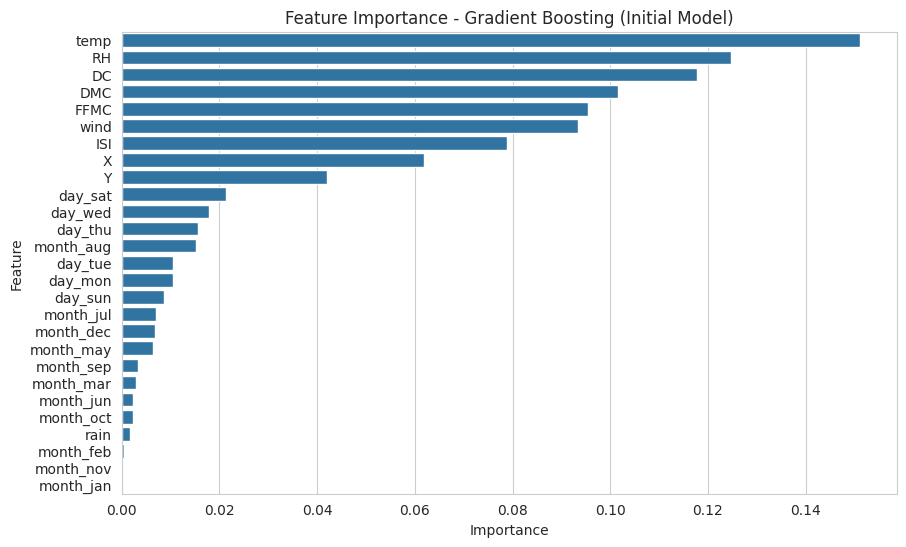

      Feature  Importance
6        temp    0.151069
7          RH    0.124748
4          DC    0.117727
3         DMC    0.101518
2        FFMC    0.095451
8        wind    0.093445
5         ISI    0.078819
0           X    0.061812
1           Y    0.041997
22    day_sat    0.021372
26    day_wed    0.017852
24    day_thu    0.015653
10  month_aug    0.015191
25    day_tue    0.010501
21    day_mon    0.010461
23    day_sun    0.008703
14  month_jul    0.007114
11  month_dec    0.006810
17  month_may    0.006326
20  month_sep    0.003421
16  month_mar    0.002995
15  month_jun    0.002380
19  month_oct    0.002283
9        rain    0.001773
12  month_feb    0.000579
18  month_nov    0.000000
13  month_jan    0.000000


In [49]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df  )
plt.title("Feature Importance - Gradient Boosting (Initial Model)")
plt.show()
print(importance_df)



# Train the model with Selected Features

In [56]:
selected_features = [
    'temp', 'DC', 'RH',
    'DMC', 'ISI','FFMC', 'wind']
X_selected = X[selected_features]
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected,  y, test_size=0.2, random_state=42,
    stratify=y)
X_train_sel_smote, y_train_sel_smote = smote.fit_resample(
    X_train_sel, y_train_sel)
gb_final = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.8,
    random_state=42)
gb_final.fit(X_train_sel_smote, y_train_sel_smote)
y_pred_final2 = gb_final.predict(X_test_sel)
y_prob_final2 = gb_final.predict_proba(X_test_sel)

print("="*60)
print("FINAL GRADIENT BOOSTING (FEATURE SELECTED MODEL)")
print("="*60)

print("\nAccuracy:", accuracy_score(y_test_sel, y_pred_final2))

print("\nF1 Score (Macro):", f1_score(y_test_sel, y_pred_final2, average='macro'))

print("\nClassification Report:\n")

print(classification_report(
    y_test_sel,
    y_pred_final,
    target_names=['No Fire','Low Fire','High Fire']
))

FINAL GRADIENT BOOSTING (FEATURE SELECTED MODEL)

Accuracy: 0.5048543689320388

F1 Score (Macro): 0.48012763329444863

Classification Report:

              precision    recall  f1-score   support

     No Fire       0.64      0.65      0.65        49
    Low Fire       0.48      0.52      0.50        27
   High Fire       0.54      0.48      0.51        27

    accuracy                           0.57       103
   macro avg       0.55      0.55      0.55       103
weighted avg       0.57      0.57      0.57       103



# GB CONFUSION MATRIX

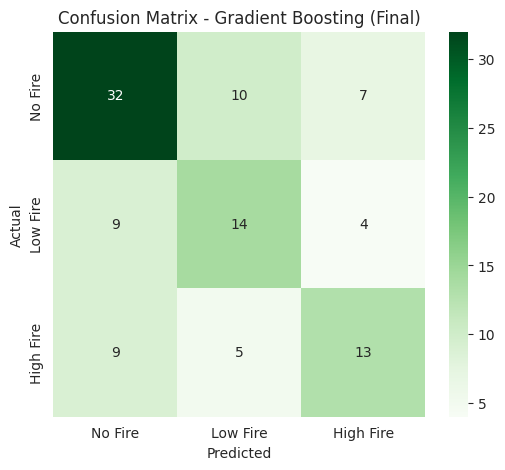

In [57]:
cm = confusion_matrix(y_test_sel, y_pred_final)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Fire','Low Fire','High Fire'],
    yticklabels=['No Fire','Low Fire','High Fire']
)

plt.title("Confusion Matrix - Gradient Boosting (Final)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC-AUC


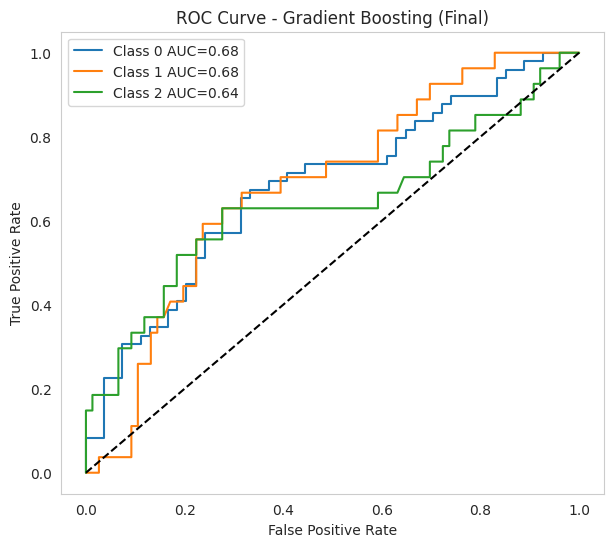

In [59]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test_sel, classes=[0,1,2])

plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_final[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} AUC={roc_auc:.2f}")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve - Gradient Boosting (Final)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

# KNN MODEL

SCALING (ONLY FOR KNN)

In [60]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [88]:
k_values = range(1, 30)
metrics_list = ['euclidean', 'manhattan', 'minkowski']
results = []
for metric in metrics_list:
    print(f"\n===== METRIC: {metric.upper()} =====")
    for k in k_values:
        model = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric)
        model.fit(X_train_scaled, y_train_smote)
        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        results.append((metric, k, acc, f1, bal_acc))
        print(f"K={k} | Acc={acc:.4f} | F1={f1:.4f} | BalAcc={bal_acc:.4f}")


===== METRIC: EUCLIDEAN =====
K=1 | Acc=0.4854 | F1=0.4554 | BalAcc=0.4565
K=2 | Acc=0.4757 | F1=0.4059 | BalAcc=0.4109
K=3 | Acc=0.4563 | F1=0.4313 | BalAcc=0.4306
K=4 | Acc=0.5437 | F1=0.4957 | BalAcc=0.4974
K=5 | Acc=0.5340 | F1=0.5005 | BalAcc=0.5016
K=6 | Acc=0.5049 | F1=0.4860 | BalAcc=0.4868
K=7 | Acc=0.5146 | F1=0.4927 | BalAcc=0.4936
K=8 | Acc=0.5340 | F1=0.5083 | BalAcc=0.5016
K=9 | Acc=0.5340 | F1=0.5082 | BalAcc=0.5072
K=10 | Acc=0.4563 | F1=0.4361 | BalAcc=0.4417
K=11 | Acc=0.5243 | F1=0.5013 | BalAcc=0.5004
K=12 | Acc=0.4466 | F1=0.4267 | BalAcc=0.4293
K=13 | Acc=0.4563 | F1=0.4424 | BalAcc=0.4417
K=14 | Acc=0.4466 | F1=0.4368 | BalAcc=0.4293
K=15 | Acc=0.4466 | F1=0.4352 | BalAcc=0.4349
K=16 | Acc=0.4563 | F1=0.4472 | BalAcc=0.4472
K=17 | Acc=0.4369 | F1=0.4183 | BalAcc=0.4114
K=18 | Acc=0.4466 | F1=0.4237 | BalAcc=0.4182
K=19 | Acc=0.4466 | F1=0.4314 | BalAcc=0.4293
K=20 | Acc=0.4466 | F1=0.4241 | BalAcc=0.4238
K=21 | Acc=0.4272 | F1=0.4061 | BalAcc=0.4046
K=22 | Acc=0

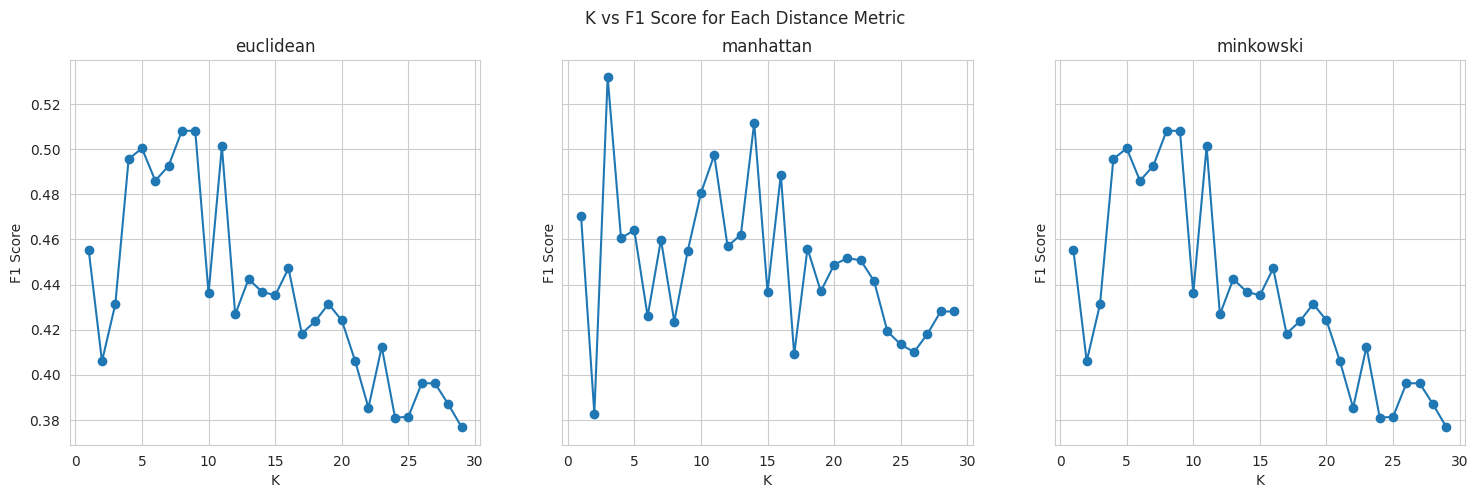

In [89]:
results_df = pd.DataFrame(results, columns=[
    'Metric', 'K', 'Accuracy', 'F1', 'Balanced_Accuracy'
])

fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

metrics = ['euclidean', 'manhattan', 'minkowski']

for i, metric in enumerate(metrics):

    subset = results_df[results_df['Metric'] == metric].sort_values('K')

    axes[i].plot(subset['K'], subset['F1'], marker='o')
    axes[i].set_title(metric)
    axes[i].set_xlabel("K")
    axes[i].set_ylabel("F1 Score")
    axes[i].grid(True)

plt.suptitle("K vs F1 Score for Each Distance Metric")
plt.show()

In [90]:
best_result = max(results, key=lambda x: x[3])

best_metric, best_k, best_acc, best_f1, best_bal = best_result

print("\n" + "="*60)
print("BEST KNN CONFIGURATION")
print("="*60)
print(f"Metric: {best_metric}")
print(f"K: {best_k}")
print(f"Accuracy: {best_acc}")
print(f"F1 Score: {best_f1}")


BEST KNN CONFIGURATION
Metric: manhattan
K: 3
Accuracy: 0.5533980582524272
F1 Score: 0.5319821238958705


In [91]:
def evaluate_knn(metric_name, k_value):

    print("\n")
    print("="*60)
    print(f"KNN MODEL | Metric={metric_name.upper()} | K={k_value}")
    print("="*60)

    model = KNeighborsClassifier(
        n_neighbors=k_value,
        metric=metric_name
    )

    model.fit(X_train_scaled, y_train_smote)
    y_pred = model.predict(X_test_scaled)

    print("\nAccuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred, average='macro'))

    print("\nClassification Report:\n")
    print(classification_report(
        y_test,
        y_pred,
        target_names=['No Fire', 'Low Fire', 'High Fire']
    ))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Oranges',
        xticklabels=['No Fire','Low Fire','High Fire'],
        yticklabels=['No Fire','Low Fire','High Fire']
    )

    plt.title(f"KNN Confusion Matrix ({metric_name}, K={k_value})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()




KNN MODEL | Metric=MANHATTAN | K=3

Accuracy: 0.5533980582524272
F1 Score: 0.5319821238958705

Classification Report:

              precision    recall  f1-score   support

     No Fire       0.63      0.63      0.63        49
    Low Fire       0.50      0.48      0.49        27
   High Fire       0.46      0.48      0.47        27

    accuracy                           0.55       103
   macro avg       0.53      0.53      0.53       103
weighted avg       0.55      0.55      0.55       103



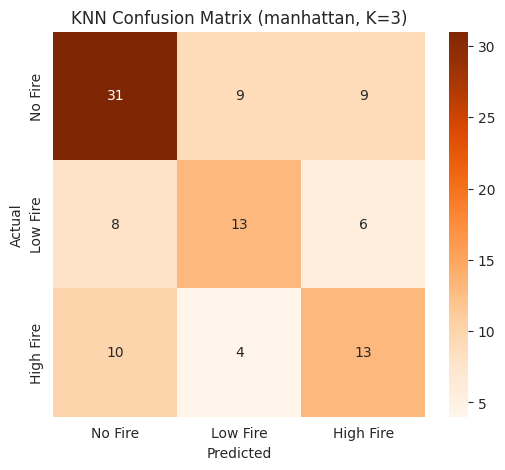

In [92]:
evaluate_knn(best_metric, best_k)

# FINAL KNN MODEL

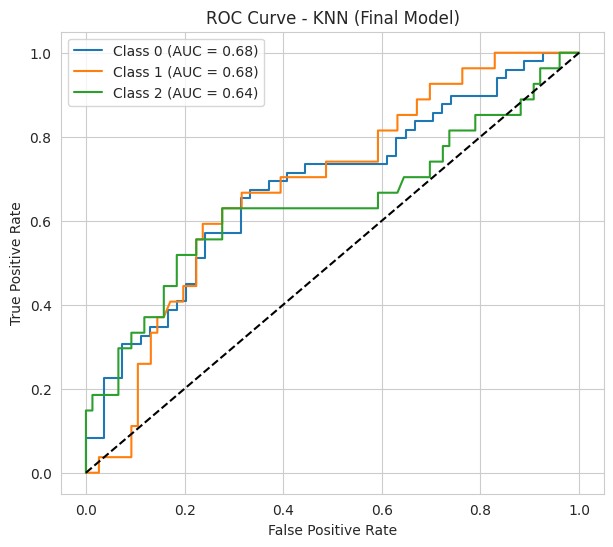

In [93]:
knn_final = KNeighborsClassifier(
    n_neighbors=best_k,
    metric=best_metric
)

knn_final.fit(X_train_scaled, y_train_smote)
y_pred_knn = knn_final.predict(X_test_scaled)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i],  y_prob_final[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - KNN (Final Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Logistic Regression
# Hyperpameter tuning

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import itertools
penalties = ['l1', 'l2']
C_values = [0.01, 0.1, 1, 10]
solvers = ['liblinear', 'saga']
max_iters = [100, 200, 500]
class_weights = [None, 'balanced']
lr_results = []

for penalty in penalties:
    for C in C_values:
        for solver in solvers:
            for max_iter in max_iters:
                for class_weight in class_weights:
                    if solver == 'lbfgs' and penalty == 'l1':
                        continue
                    if solver == 'liblinear' and penalty not in ['l1', 'l2']:
                        continue
                    if solver == 'saga' and penalty not in ['l1', 'l2']:
                        continue
                    model = LogisticRegression(
                        penalty=penalty,
                        C=C,
                        solver=solver,
                        max_iter=max_iter,
                        class_weight=class_weight
                    )

                    model.fit(X_train_smote, y_train_smote)
                    y_pred = model.predict(X_test)

                    acc = accuracy_score(y_test, y_pred)
                    f1 = f1_score(y_test, y_pred, average='macro')

                    lr_results.append((penalty, C, solver, max_iter, class_weight, acc, f1))

                    print(f"{penalty}, C={C}, solver={solver}, max_iter={max_iter}, class_weight={class_weight} | Acc={acc:.4f} | F1={f1:.4f}")

l1, C=0.01, solver=liblinear, max_iter=100, class_weight=None | Acc=0.3592 | F1=0.3281
l1, C=0.01, solver=liblinear, max_iter=100, class_weight=balanced | Acc=0.3592 | F1=0.3281
l1, C=0.01, solver=liblinear, max_iter=200, class_weight=None | Acc=0.3592 | F1=0.3281
l1, C=0.01, solver=liblinear, max_iter=200, class_weight=balanced | Acc=0.3592 | F1=0.3281
l1, C=0.01, solver=liblinear, max_iter=500, class_weight=None | Acc=0.3592 | F1=0.3281
l1, C=0.01, solver=liblinear, max_iter=500, class_weight=balanced | Acc=0.3592 | F1=0.3281
l1, C=0.01, solver=saga, max_iter=100, class_weight=None | Acc=0.3981 | F1=0.3699


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


l1, C=0.01, solver=saga, max_iter=100, class_weight=balanced | Acc=0.3981 | F1=0.3699
l1, C=0.01, solver=saga, max_iter=200, class_weight=None | Acc=0.3981 | F1=0.3699
l1, C=0.01, solver=saga, max_iter=200, class_weight=balanced | Acc=0.3981 | F1=0.3699
l1, C=0.01, solver=saga, max_iter=500, class_weight=None | Acc=0.3981 | F1=0.3699
l1, C=0.01, solver=saga, max_iter=500, class_weight=balanced | Acc=0.3981 | F1=0.3699
l1, C=0.1, solver=liblinear, max_iter=100, class_weight=None | Acc=0.3786 | F1=0.3615
l1, C=0.1, solver=liblinear, max_iter=100, class_weight=balanced | Acc=0.3786 | F1=0.3615
l1, C=0.1, solver=liblinear, max_iter=200, class_weight=None | Acc=0.3786 | F1=0.3615
l1, C=0.1, solver=liblinear, max_iter=200, class_weight=balanced | Acc=0.3786 | F1=0.3615
l1, C=0.1, solver=liblinear, max_iter=500, class_weight=None | Acc=0.3786 | F1=0.3615
l1, C=0.1, solver=liblinear, max_iter=500, class_weight=balanced | Acc=0.3786 | F1=0.3615


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


l1, C=0.1, solver=saga, max_iter=100, class_weight=None | Acc=0.3398 | F1=0.3105
l1, C=0.1, solver=saga, max_iter=100, class_weight=balanced | Acc=0.3398 | F1=0.3105


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


l2, C=10, solver=saga, max_iter=100, class_weight=balanced | Acc=0.3786 | F1=0.3594
l2, C=10, solver=saga, max_iter=200, class_weight=None | Acc=0.3981 | F1=0.3808
l2, C=10, solver=saga, max_iter=200, class_weight=balanced | Acc=0.3981 | F1=0.3813


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


l2, C=10, solver=saga, max_iter=500, class_weight=None | Acc=0.3786 | F1=0.3517
l2, C=10, solver=saga, max_iter=500, class_weight=balanced | Acc=0.3786 | F1=0.3517


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [68]:
lr_df = pd.DataFrame(lr_results, columns=[
    'penalty', 'C', 'solver', 'max_iter', 'class_weight', 'Accuracy', 'F1'
])
best_row = lr_df.loc[lr_df['F1'].idxmax()]

print("Best Parameters:")
print(best_row)

Best Parameters:
penalty                l1
C                    10.0
solver          liblinear
max_iter              100
class_weight         None
Accuracy         0.466019
F1               0.426016
Name: 36, dtype: object


In [69]:
final_model = LogisticRegression(
    penalty=best_row['penalty'],
    C=best_row['C'],
    solver=best_row['solver'],
    max_iter=int(best_row['max_iter']),
    class_weight=best_row['class_weight']
)

final_model.fit(X_train_smote, y_train_smote)
y_final = final_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_final))
print("F1 Score:", f1_score(y_test, y_final, average='macro'))
print("\nClassification Report:\n")
print(classification_report(y_test, y_final))

Accuracy: 0.46601941747572817
F1 Score: 0.426016441617379

Classification Report:

              precision    recall  f1-score   support

           0       0.54      0.59      0.56        49
           1       0.33      0.22      0.27        27
           2       0.42      0.48      0.45        27

    accuracy                           0.47       103
   macro avg       0.43      0.43      0.43       103
weighted avg       0.45      0.47      0.46       103



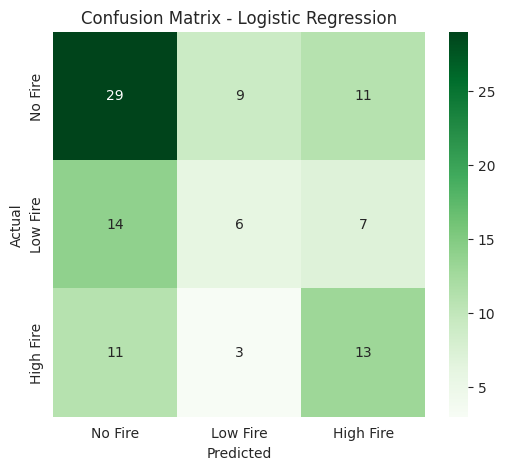

In [95]:
cm = confusion_matrix(y_test, y_final)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Fire','Low Fire','High Fire'],
    yticklabels=['No Fire','Low Fire','High Fire']
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

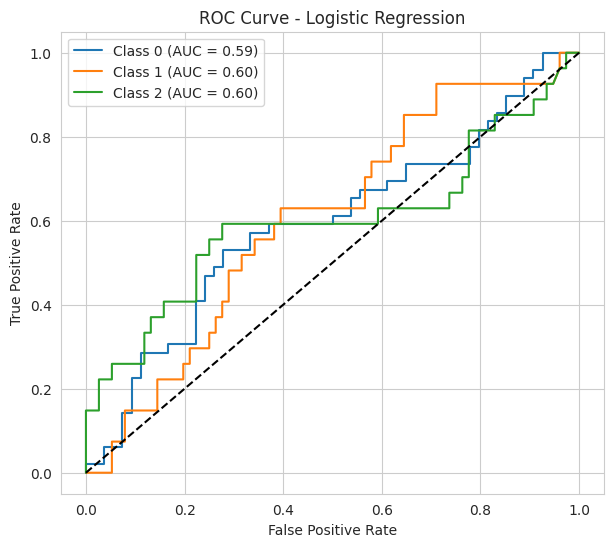

In [97]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]
y_score = final_model.predict_proba(X_test)

plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

In [70]:
selector_model = LogisticRegression(
    penalty=best_row['penalty'],
    solver=best_row['solver'],
    C=best_row['C'],
    class_weight=best_row['class_weight'],
    max_iter=int(best_row['max_iter'])
)

selector_model.fit(X_train_smote, y_train_smote)
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(selector_model, prefit=True)

X_train_fs = selector.transform(X_train_smote)
X_test_fs = selector.transform(X_test)

print("Before:", X_train_smote.shape[1])
print("After:", X_train_fs.shape[1])

Before: 27
After: 25


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [71]:
final_fs_model = LogisticRegression(
    penalty=best_row['penalty'],
    C=best_row['C'],
    solver=best_row['solver'],
    max_iter=int(best_row['max_iter']),
    class_weight=best_row['class_weight']
)

final_fs_model.fit(X_train_fs, y_train_smote)
y_pred_fs = final_fs_model.predict(X_test_fs)

print("Accuracy:", accuracy_score(y_test, y_pred_fs))
print("F1:", f1_score(y_test, y_pred_fs, average='macro'))
print(classification_report(y_test, y_pred_fs))

Accuracy: 0.46601941747572817
F1: 0.426016441617379
              precision    recall  f1-score   support

           0       0.54      0.59      0.56        49
           1       0.33      0.22      0.27        27
           2       0.42      0.48      0.45        27

    accuracy                           0.47       103
   macro avg       0.43      0.43      0.43       103
weighted avg       0.45      0.47      0.46       103



In [82]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

fs_acc = accuracy_score(y_test, y_pred_fs)
fs_precision = precision_score(y_test, y_pred_fs, average='macro')
fs_recall = recall_score(y_test, y_pred_fs, average='macro')
fs_f1 = f1_score(y_test, y_pred_fs, average='macro')

# FINAL MODEL COMPARISON TABLE

In [94]:
comparison_df = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "KNN",
        "Logistic Regression"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_rf_final),
        accuracy_score(y_test, y_pred_final),
        accuracy_score(y_test, y_pred_knn),
        fs_acc
    ],

    "Precision": [
        precision_score(y_test, y_pred_rf_final, average='macro'),
        precision_score(y_test, y_pred_final, average='macro'),
        precision_score(y_test, y_pred_knn, average='macro'),
        fs_precision
    ],

    "Recall": [
        recall_score(y_test, y_pred_rf_final, average='macro'),
        recall_score(y_test, y_pred_final, average='macro'),
        recall_score(y_test, y_pred_knn, average='macro'),
        fs_recall
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_rf_final, average='macro'),
        f1_score(y_test, y_pred_final, average='macro'),
        f1_score(y_test, y_pred_knn, average='macro'),
        fs_f1
    ]
})

print("\nFINAL MODEL COMPARISON\n")
print(comparison_df)


FINAL MODEL COMPARISON

                 Model  Accuracy  Precision    Recall  F1 Score
0        Random Forest  0.543689   0.506039  0.497354  0.499346
1    Gradient Boosting  0.572816   0.554808  0.551020  0.552090
2                  KNN  0.553398   0.532313  0.531872  0.531982
3  Logistic Regression  0.466019   0.429908  0.431847  0.426016


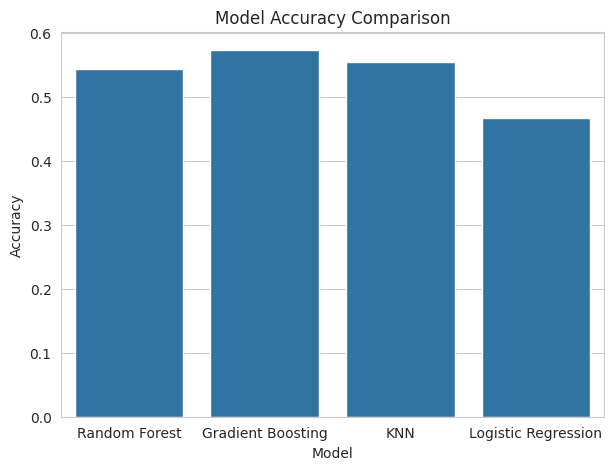

In [76]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison_df
)

plt.title("Model Accuracy Comparison")

plt.show()

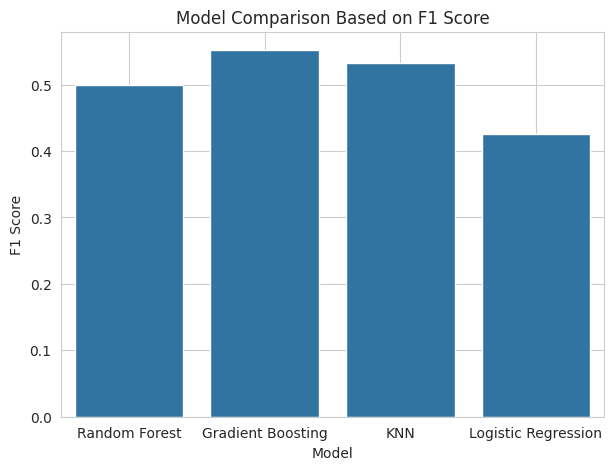

In [77]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Model",
    y="F1 Score",
    data=comparison_df
)

plt.title("Model Comparison Based on F1 Score")
plt.ylabel("F1 Score")
plt.xlabel("Model")

plt.grid(True)
plt.show()

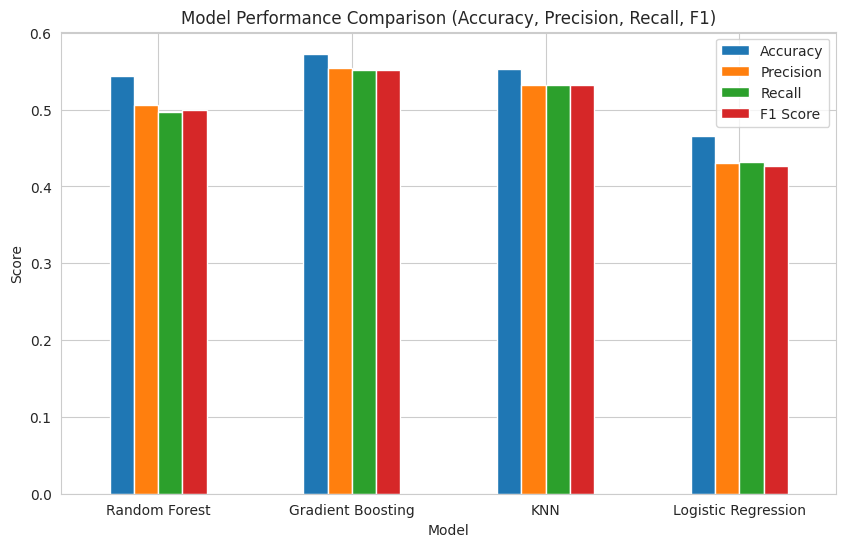

In [78]:
comparison_df.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]].plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison (Accuracy, Precision, Recall, F1)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

In [79]:
comparison_df["Combined Score"] = (
    comparison_df["Accuracy"] +
    comparison_df["F1 Score"]
) / 2

best_model = comparison_df.loc[
    comparison_df["Combined Score"].idxmax()
]

print("\nBEST MODEL (Accuracy + F1 Score)\n")
print(best_model)


BEST MODEL (Accuracy + F1 Score)

Model             Gradient Boosting
Accuracy                   0.572816
Precision                  0.554808
Recall                      0.55102
F1 Score                    0.55209
Combined Score             0.562453
Name: 1, dtype: object
